In [1]:
# This cell does not render in the docs because it has a `nbsphinx: hidden` tag.

%load_ext autoreload
%autoreload 2

import warnings

warnings.filterwarnings("ignore")

# Gene Expression Embeddings (Bone Marrow)

UMAP is one of the most widely used tools for visualizing single-cell RNA-seq data, but standard UMAP is a black box: you can see that cells form clusters, but you can't ask *why* a particular cell ended up where it did. Which genes are responsible for placing a monocyte here and a T cell there?

Glass Box UMAP answers this question. Because the encoder is a differentiable neural network, we can compute the exact Jacobian of the embedding with respect to the input features. Multiplying the Jacobian by each cell's gene expression gives a per-gene, per-cell contribution score that decomposes the embedding position into individual gene effects. In short: for every cell, you get a vector telling you how much each gene pushed it in the embedding.

In this tutorial, we train a Glass Box UMAP on bone marrow single-cell RNA-seq data (BMMC), then use these Jacobian-based contributions to identify which genes most strongly drive each cell type's position in the embedding.

Given the ubiquitous use of [scanpy](https://scanpy.readthedocs.io/en/stable/) and [anndata](https://anndata.readthedocs.io/en/stable/) in single-cell analysis, this tutorial illustrates how to interface between these tools and Glass Box UMAP. These are external dependencies you should install separately if you wish to follow along.

## Load and Prepare Data

We use a bone marrow mononuclear cell (BMMC) dataset from the [NeurIPS 2021 Open Problems in Single-Cell Analysis](https://openproblems.bio/) benchmark. This dataset contains ~90,000 cells across dozens of cell types, making it a good stress test for interpretable dimensionality reduction.

First, we download the data.

In [2]:
import anndata as ad
import scanpy as sc
import urllib.request
import shutil
import gzip

from pathlib import Path

URL = (
    "ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE194nnn/GSE194122/suppl/"
    "GSE194122_openproblems_neurips2021_cite_BMMC_processed.h5ad.gz"
)

def _download_bone_marrow_data() -> Path:
    dl_path = Path("GSE194122_openproblems_neurips2021_cite_BMMC_processed.h5ad.gz")
    unzipped_path = dl_path.with_suffix("")
    if not unzipped_path.exists():
        if not dl_path.exists():
            urllib.request.urlretrieve(URL, dl_path)
        with gzip.open(dl_path, "rb") as f_in, open(unzipped_path, "wb") as f_out:
            shutil.copyfileobj(f_in, f_out)
        dl_path.unlink()

    return unzipped_path

Then, we apply a standard preprocessing pipeline and return an [AnnData](https://anndata.readthedocs.io/en/stable/) object. A few choices here are worth explaining:

- **Removing mitochondrial and ribosomal genes.** These genes reflect cell stress and housekeeping activity rather than cell identity. Leaving them in would allow them to dominate the contributions, masking the biologically interesting signal.
- **Selecting highly variable genes (HVGs).** Most genes in a scRNA-seq dataset show little variation across cells and carry minimal information about cell identity. Restricting to the top 2000 HVGs focuses the model on genes with discriminative power. Since Glass Box UMAP computes contributions in the space of input features, this choice directly determines which genes can appear in the interpretation.
- **Regressing out total counts.** Sequencing depth varies across cells for technical reasons. Without regression, depth-related variation would appear in the embedding and contaminate the gene contributions. Regressing out total counts removes this confounder so that the contributions reflect biology, not sequencing artifacts.

In [3]:
def prepare_data(
    n_top_genes: int = 2000,
    min_genes: int = 100,
    min_cells: int = 3,
    n_top_cell_types: int = 32,
) -> ad.AnnData:
    """Load, preprocess, and subset to top cell types.

    Args:
        n_top_genes: Number of highly variable genes to select.
        min_genes: Minimum number of genes expressed per cell.
        min_cells: Minimum number of cells expressing a gene.
        n_top_cell_types: Number of most frequent cell types to keep.
    """
    cache_path = Path("adata_processed.h5ad")
    if cache_path.exists():
        return sc.read_h5ad(cache_path)

    adata = sc.read_h5ad(_download_bone_marrow_data())
    adata.obs_names_make_unique()
    adata.var_names_make_unique()

    # Flag QC gene categories
    adata.var["mt"] = adata.var_names.str.startswith("MT-")
    adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
    adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")
    adata.var["technical"] = adata.var_names.str.startswith(("MALAT1", "NEAT1", "FOS", "JUN"))

    sc.pp.calculate_qc_metrics(
        adata,
        qc_vars=["mt", "ribo", "hb", "technical"],
        inplace=True,
        log1p=True,
    )

    # Remove QC genes, filter cells/genes
    genes_to_remove = adata.var["mt"] | adata.var["ribo"]
    adata._inplace_subset_var(~genes_to_remove)
    sc.pp.filter_cells(adata, min_genes=min_genes)
    sc.pp.filter_genes(adata, min_cells=min_cells)

    # Normalize, log-transform, HVGs
    adata.layers["counts"] = adata.X.copy()
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)

    sc.pp.highly_variable_genes(adata, n_top_genes=n_top_genes, batch_key="Samplename")

    # Now regress out on the full matrix (or subset to HVGs first)
    sc.pp.regress_out(adata, ["total_counts"])

    # Subset to top cell types
    top_types = adata.obs["cell_type"].value_counts().nlargest(n_top_cell_types).index
    adata = adata[adata.obs["cell_type"].isin(top_types)].copy()

    adata.write_h5ad(cache_path)
    return adata

adata = prepare_data()

print(f"Cells: {adata.n_obs}, Genes: {adata.n_vars}")

Cells: 87549, Genes: 13980


## Extract arrays

Before fitting the model, we extract the arrays we need from the AnnData object. Glass Box UMAP operates on plain numpy arrays (or torch tensors), so this is where we bridge from the scanpy/anndata world.

We extract four things:

1. `X` -- the expression matrix, subset to HVGs only. Shape: (n_cells, 2000). This is what the model sees, and therefore what it can attribute contributions to. Any gene not in this matrix is invisible to the model.
2. `gene_names` -- the name of each HVG, so we can label contributions with actual gene symbols.
3. `cell_type_ids` and `cell_type_names` -- integer-coded cell type labels and their human-readable names. These aren't used for training (UMAP is unsupervised), but we'll use them to color the embedding and validate that the contributions make biological sense.

In [4]:
X = adata[:, adata.var.highly_variable].X
gene_names = adata[:, adata.var.highly_variable].var_names.values
cell_type_names = list(adata.obs["cell_type"].cat.categories)
cell_type_ids = adata.obs["cell_type"].astype("category").cat.codes.values

print(f"X: {type(X).__name__}, shape {X.shape}")
print(f"gene_names: {type(gene_names).__name__}, shape {gene_names.shape}")
print(f"cell_type_names: {type(cell_type_names).__name__}, length {len(cell_type_names)}")
print(f"cell_type_ids: {type(cell_type_ids).__name__}, shape {cell_type_ids.shape}")

X: ArrayView, shape (87549, 2000)
gene_names: ndarray, shape (2000,)
cell_type_names: list, length 32
cell_type_ids: ndarray, shape (87549,)


## Fit Glass Box UMAP

We create a `GlassBoxUMAP` instance and fit it on the expression matrix. The API mirrors scikit-learn: `fit` learns the embedding, and `transform` projects data into the learned space.

Note the `pca_components=200` parameter. In single-cell analysis, it is common practice to apply PCA before dimensionality reduction because the gene expression matrix is very high-dimensional (~2000 HVGs) and often sparse. PCA compresses the data into a lower-dimensional, dense representation that the encoder can learn from more efficiently. Glass Box UMAP applies PCA internally and -- crucially -- projects the Jacobian back through the PCA transformation, so the final contributions are still reported in terms of individual genes, not principal components.

In [6]:
from glass_box_umap import GlassBoxUMAP

reducer = GlassBoxUMAP(
    epochs=4,
    lr=1e-4,
    batch_size=128 * 32,
    num_batches=900,
    repulsion_strength=1.0,
    min_dist=2.0,
    n_neighbors=64,
    random_state=42,
    pca_components=200,
)

reducer.fit(X)
embedding = reducer.transform(X)

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


Wed Apr 15 19:29:37 2026 Building RP forest with 20 trees
Wed Apr 15 19:29:39 2026 NN descent for 16 iterations
	 1  /  16
	 2  /  16
	 3  /  16
	 4  /  16
	Stopping threshold met -- exiting after 4 iterations


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type         ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder │ DeepPReLUNet │  314 K │ train │     0 │
└───┴─────────┴──────────────┴────────┴───────┴───────┘

Trainable params: 314 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 314 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 23                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_epochs=4` reached.


## Plot Embedding

As a sanity check, we plot the embedding colored by the known cell type labels. This verifies that the model has learned a meaningful structure before we move on to interpreting it.

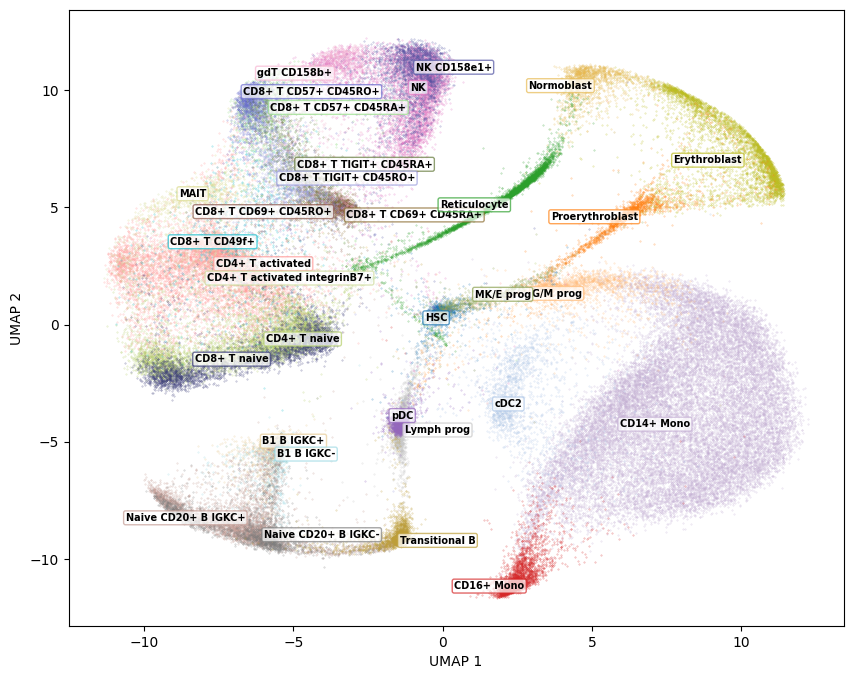

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from glass_box_umap.plotting import plot_embedding

fig = plot_embedding(Z=embedding, group_ids=cell_type_ids, group_names=cell_type_names)
fig.show()

## Compute feature contributions

This is the core of Glass Box UMAP. `compute_contributions` computes the Jacobian of the encoder with respect to the input, then multiplies it element-wise by each cell's gene expression. The result is a contribution array of shape `(n_cells, n_components, n_genes)`: for each cell, for each embedding dimension, the contribution of every gene. Positive values mean the gene pushed the cell in the positive direction along that embedding axis; negative values mean it pushed in the opposite direction.

To visualize this, we need to summarize across embedding dimensions. `groups_from_top_features` does this by first taking the L2 norm across components (collapsing the 2D directional information into a single magnitude per gene per cell), then assigning each cell to its single highest-contributing gene. It keeps only the `n_top` most frequently "winning" genes and returns group IDs suitable for plotting. Cells whose top gene didn't make the cut are dropped.

The resulting plot colors each cell by the gene that contributes most to its embedding position. Spatially coherent gene regions indicate that the model has learned biologically meaningful structure -- for example, you might see hemoglobin genes dominating the erythroid progenitor region, or S100 family genes marking monocytes.

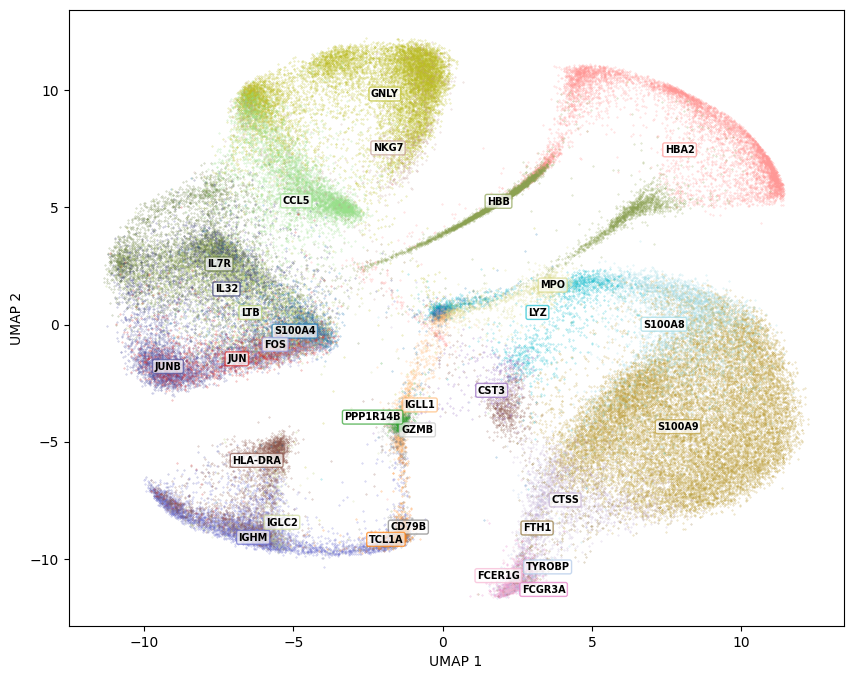

In [31]:
from glass_box_umap.jacobian import groups_from_top_features

contributions = reducer.compute_contributions(X)
group_ids, group_names, mask = groups_from_top_features(contributions, gene_names, n_top=30)

fig = plot_embedding(Z=embedding[mask, ...], group_ids=group_ids, group_names=group_names)
fig.show()

## Conclusion

This tutorial showed the basic workflow: fit a Glass Box UMAP, compute per-gene contributions, and visualize which genes drive the embedding. But coloring by the single top gene per cell is just one way to use the contribution scores. The full `(n_cells, n_components, n_genes)` array is a rich object that supports many downstream analyses:

- **Per-cluster gene ranking.** Average the contributions within each cell type to identify the genes that most distinguish each cluster -- similar to marker gene analysis, but derived from the embedding structure rather than differential expression.
- **Directional contributions.** Instead of collapsing to L2 norms, inspect contributions per embedding axis to understand which genes drive separation along specific directions.
- **Quality control.** Check whether technical artifacts (sequencing depth, batch effects) appear in the top contributions. If they do, it may indicate preprocessing issues.